#### Core Classes (Concepts)

These define the main entities in a CNC domain:

* Machine
    * CNC Milling Machine
    * Spindle
    * Controller
* Tool
    * End Mill
    * Drill
    * Tool Holder (e.g., Smart Tool Holder)
* Workpiece
    * Material (e.g., Ti-6Al-4V, Aluminum)
    * Geometry
* Process Parameters
    * Spindle Speed (N)
    * Feed Rate (f)
    * Axial Depth (ap)
    * Radial Depth (ae)
* Signals / Sensors
    * Force
    * Vibration
    * Torque
    * Temperature
* Quality / Output
    * Surface Roughness (Ra)
    * Tool Wear
    * Dimensional Accuracy

#### Relationships (Key Ontology Links)

These define how entities interact:

* Machine → uses → Tool
* Tool → cuts → Workpiece
* Process Parameters → influence → Cutting Force
* Cutting Force → affects → Tool Wear
* Tool Wear → degrades → Surface Quality
* Sensors → measure → Physical Signals
* Signals → infer → Process State (e.g., chatter, stable cutting)

### Formalized Example (Triple Representation) 

Ontology is often expressed as subject–predicate–object:

* (EndMill) → cuts → (Titanium Workpiece)
* (SpindleSpeed) → affects → (CuttingForce)
* (VibrationSignal) → indicates → (ChatterState)
* (ToolWear) → increases → (SurfaceRoughness)

The vibration signal is exposed by a specific OPC UA node, published on a specific MQTT topic, and encoded by a specific JSON field.

| Layer    | Role   |Representation            |
| -------- | -------| ------------------------ |
| JSON     | data exchange |`torque_nm`             |
| MQTT     | transport | `factory/cncA/sth01/torque` |
| OPC UA   | structured machine model | `ns=4;s=...Torque`          |
| TTL (Ontology) | semantic integration| `TorqueSignal`            |


Root base URI: http://nkust.edu.tw/mislab/cnc/

It uses your unified standard:

* root: http://nkust.edu.tw/mislab/cnc/
* MQTT root: nkust/mislab/cnc/
* ontology namespace: http://nkust.edu.tw/mislab/cnc/ontology/sth#
* OPC UA namespace: http://nkust.edu.tw/mislab/cnc/opcua/sth/
* schema base: http://nkust.edu.tw/mislab/cnc/schema/

http://nkust.edu.tw/mislab/cnc/
├── ontology/
│   └── sth#
├── opcua/
│   └── sth/
└── schema/
    ├── process-parameters.schema.json
    ├── sth-identification.schema.json
    ├── torque-signal.schema.json
    ├── vibration-signal.schema.json
    ├── feature-bundle.schema.json
    ├── chatter-diagnosis.schema.json
    ├── tool-wear-prediction.schema.json
    ├── quality-estimate.schema.json
    └── sth-health.schema.json

When registered in the server:

In [2]:
from rdflib import Graph

# Load TTL file
g = Graph()
g.parse("ontology/TMV-720.ttl", format="turtle")

print(f"Total triples: {len(g)}")

Total triples: 592


In [3]:
for subj, pred, obj in g:
    print(f"{subj}  --> {pred}  --> {obj}")

http://nkust.edu.tw/mislab#2026SBIR_FinishCut_Ra_1  --> http://nkust.edu.tw/mislab#hasTolerance  --> 0.01
http://nkust.edu.tw/mislab/cnc/ontology/sth#SevereWear  --> http://www.w3.org/2000/01/rdf-schema#subClassOf  --> http://nkust.edu.tw/mislab/cnc/ontology/sth#ToolCondition
http://nkust.edu.tw/mislab/cnc/ontology/sth#mapsToMQTTTopic  --> http://www.w3.org/1999/02/22-rdf-syntax-ns#type  --> http://www.w3.org/2002/07/owl#ObjectProperty
http://nkust.edu.tw/mislab#Ti_Gr2  --> http://purl.org/dc/elements/1.1/date  --> 2026-04-22T03:05:59+00:00
http://nkust.edu.tw/mislab/cnc/ontology/sth#Topic_Torque  --> http://www.w3.org/1999/02/22-rdf-syntax-ns#type  --> http://nkust.edu.tw/mislab/cnc/ontology/sth#MQTTTopic
http://nkust.edu.tw/mislab/cnc/ontology/sth#Window_w10233  --> http://nkust.edu.tw/mislab/cnc/ontology/sth#hasEndTime  --> 2026-04-13T10:00:00.400000
http://nkust.edu.tw/mislab/cnc/ontology/sth#Ra_01  --> http://nkust.edu.tw/mislab/cnc/ontology/sth#hasUnit  --> um
http://nkust.edu.tw

Example: show signal → state relations

In [4]:
from rdflib.namespace import Namespace

EX = Namespace("http://example.org/sth-i40-ontology#")

for s, p, o in g.triples((None, EX.indicatesState, None)):
    print(f"{s} indicates state {o}")

C:\Users\hao\anaconda3\envs\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38534 (\N{CJK UNIFIED IDEOGRAPH-9686}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hao\anaconda3\envs\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23500 (\N{CJK UNIFIED IDEOGRAPH-5BCC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hao\anaconda3\envs\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30332 (\N{CJK UNIFIED IDEOGRAPH-767C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hao\anaconda3\envs\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26481 (\N{CJK UNIFIED IDEOGRAPH-6771}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hao\anaconda3\envs\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21488

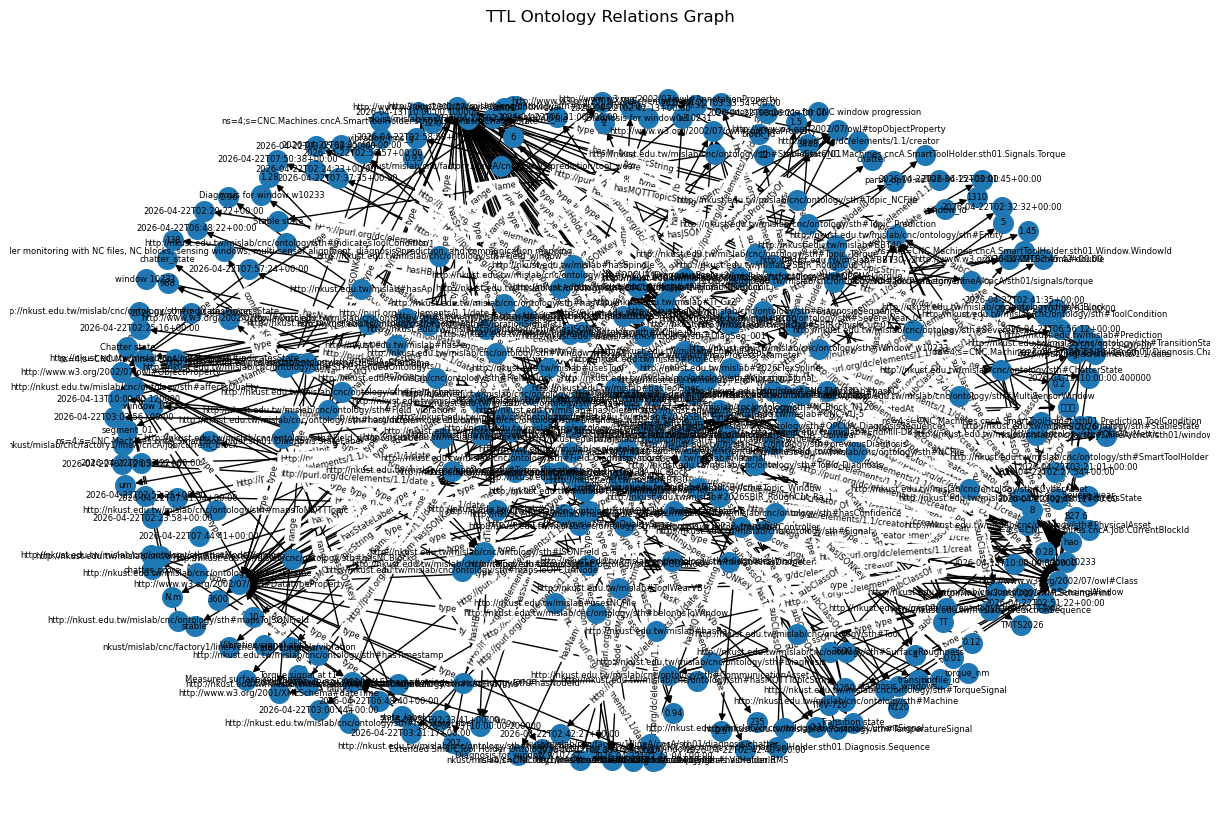

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for s, p, o in g:
    G.add_edge(str(s), str(o), label=str(p).split("#")[-1])

# Draw graph (small graphs only!)
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5)

nx.draw(G, pos, with_labels=True, node_size=200, font_size=6)

edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)

plt.title("TTL Ontology Relations Graph")
plt.show()

In [6]:
query = """
PREFIX ex: <http://example.org/sth-i40-ontology#>

SELECT ?signal ?state
WHERE {
    ?signal ex:indicatesState ?state .
}
"""

for row in g.query(query):
    print(f"{row.signal} → {row.state}")